### SAR comparison between TA, ISO and TSV

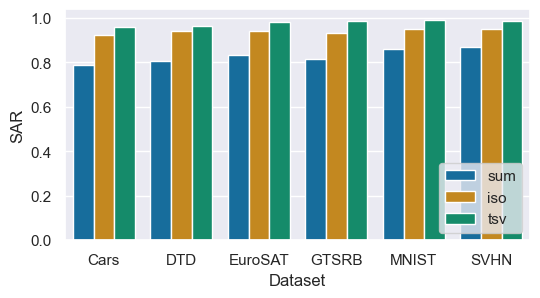

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme()
sns.set_palette("colorblind")

sar = { 
    "sum": {"Cars": 0.78620523, "DTD": 0.8081219, "EuroSAT": 0.8315229, "GTSRB": 0.816833, "MNIST": 0.8613162, "SVHN": 0.8681785}, 
    "iso":  {"Cars": 0.92468745, "DTD": 0.9393305, "EuroSAT": 0.9413924, "GTSRB": 0.93364024, "MNIST": 0.9489486, "SVHN": 0.9522428},
    "tsv": {"Cars": 0.96024275, "DTD": 0.9621821, "EuroSAT": 0.98246443, "GTSRB": 0.9853669, "MNIST": 0.9894316, "SVHN": 0.9872684}
}

data = [{'Dataset': ds, 'Method': m, 'SAR': v} for m, d in sar.items() for ds, v in d.items()]
df = pd.DataFrame(data)

plt.figure(figsize=(6, 3))
sns.barplot(data=df, x="Dataset", y="SAR", hue="Method")
plt.legend(loc='lower right')
plt.show()

### Layer-wise statistics

In [1]:
import sys
from pathlib import Path

# Allow importing the local `src` package
sys.path.append(str(Path.cwd().parent))


In [2]:
# Load model for Cars
import torch
import certifi
import os

os.environ['SSL_CERT_FILE'] = certifi.where()

from src.models.modeling import ImageClassifier, ImageEncoder
from src.models.heads import build_classification_head
from src.datasets.templates import get_templates

dataset_name = "CIFAR10"
batch_size = 32
template = get_templates(dataset_name)
data_location = "datasets"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "ViT-B-16"

# Build model
image_encoder = ImageEncoder(model_name, keep_lang=True)

classification_head = build_classification_head(image_encoder.model, dataset_name, template, data_location, device)
model = ImageClassifier(image_encoder, classification_head)


/Users/marawangamal/Documents/github/task_singular_vectors/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marawangamal/Documents/github/task_singular_vectors/.venv/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Building classification head.


100%|██████████| 10/10 [00:01<00:00,  7.83it/s]

zeroshot shape, Ptorch.Size([10, 512])


In [ ]:
from src.datasets.registry import get_dataset
from src.datasets.common import get_dataloader_v2, maybe_dictionarize

dataset_name = "CIFAR10"
batch_size = 32
dataset = get_dataset(
    dataset_name,
    model.val_preprocess,
    location=data_location,
    batch_size=batch_size,
)
dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=batch_size, device=device)

In [ ]:
# Pass single batch and measure mean and std of all activations
data = maybe_dictionarize(next(iter(dataloader)))
x = data['images']
out = model(x)
# >>> out.shape
# torch.Size([32, 1000])

In [21]:
import torch

stats = {}

def stat(x):
    x = x.detach().float()
    return x.mean().item(), x.std(unbiased=False).item(), tuple(x.shape)

hooks = []

def hook(name):
    def h(_m, _i, o):
        if torch.is_tensor(o):
            stats[name] = stat(o)
    return h

enc = model.image_encoder  # or model.image_encoder.model.visual

for n, m in enc.named_modules():
    if isinstance(m, torch.nn.Linear):
        hooks.append(m.register_forward_hook(hook(n)))

x = maybe_dictionarize(next(iter(dataloader)))["images"]

with torch.no_grad():
    model(x)

for h in hooks:
    h.remove()

for k, (mu, sd, sh) in sorted(stats.items()):
    print(f"{k:40s} {sh}  μ={mu:.3g} σ={sd:.3g}")


model.visual.transformer.resblocks.0.mlp.c_fc (32, 197, 3072)  μ=-1.47 σ=1.9
model.visual.transformer.resblocks.0.mlp.c_proj (32, 197, 768)  μ=-0.00643 σ=0.118
model.visual.transformer.resblocks.1.mlp.c_fc (32, 197, 3072)  μ=-0.859 σ=0.851
model.visual.transformer.resblocks.1.mlp.c_proj (32, 197, 768)  μ=0.00434 σ=0.124
model.visual.transformer.resblocks.10.mlp.c_fc (32, 197, 3072)  μ=-3.03 σ=2.06
model.visual.transformer.resblocks.10.mlp.c_proj (32, 197, 768)  μ=-0.00165 σ=0.214
model.visual.transformer.resblocks.11.mlp.c_fc (32, 197, 3072)  μ=-0.842 σ=0.76
model.visual.transformer.resblocks.11.mlp.c_proj (32, 197, 768)  μ=-0.00699 σ=0.236
model.visual.transformer.resblocks.2.mlp.c_fc (32, 197, 3072)  μ=-0.667 σ=0.742
model.visual.transformer.resblocks.2.mlp.c_proj (32, 197, 768)  μ=-0.00219 σ=0.111
model.visual.transformer.resblocks.3.mlp.c_fc (32, 197, 3072)  μ=-0.599 σ=0.745
model.visual.transformer.resblocks.3.mlp.c_proj (32, 197, 768)  μ=-2.38e-05 σ=0.105
model.visual.transformer

In [22]:
stats

{'model.visual.transformer.resblocks.0.mlp.c_fc': (-1.4697901010513306,
  1.898494005203247,
  (32, 197, 3072)),
 'model.visual.transformer.resblocks.0.mlp.c_proj': (-0.006426222622394562,
  0.11794182658195496,
  (32, 197, 768)),
 'model.visual.transformer.resblocks.1.mlp.c_fc': (-0.8588884472846985,
  0.8510082364082336,
  (32, 197, 3072)),
 'model.visual.transformer.resblocks.1.mlp.c_proj': (0.004336865618824959,
  0.12350844591856003,
  (32, 197, 768)),
 'model.visual.transformer.resblocks.2.mlp.c_fc': (-0.6671441197395325,
  0.7421253323554993,
  (32, 197, 3072)),
 'model.visual.transformer.resblocks.2.mlp.c_proj': (-0.002186467871069908,
  0.11072870343923569,
  (32, 197, 768)),
 'model.visual.transformer.resblocks.3.mlp.c_fc': (-0.5986319780349731,
  0.7449847459793091,
  (32, 197, 3072)),
 'model.visual.transformer.resblocks.3.mlp.c_proj': (-2.381700869591441e-05,
  0.1053268313407898,
  (32, 197, 768)),
 'model.visual.transformer.resblocks.4.mlp.c_fc': (-0.7926779389381409,
  

In [ ]:
!pip install seaborn
!pip install matplotlib
!pip install pandas


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.2 MB/s  0:00:06m0:00:0100:01
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.2 MB/s  0:00:02 eta 0:00:01
Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl (65 kB)
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m5/7 [matplotlib]


/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_23209/508623562.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


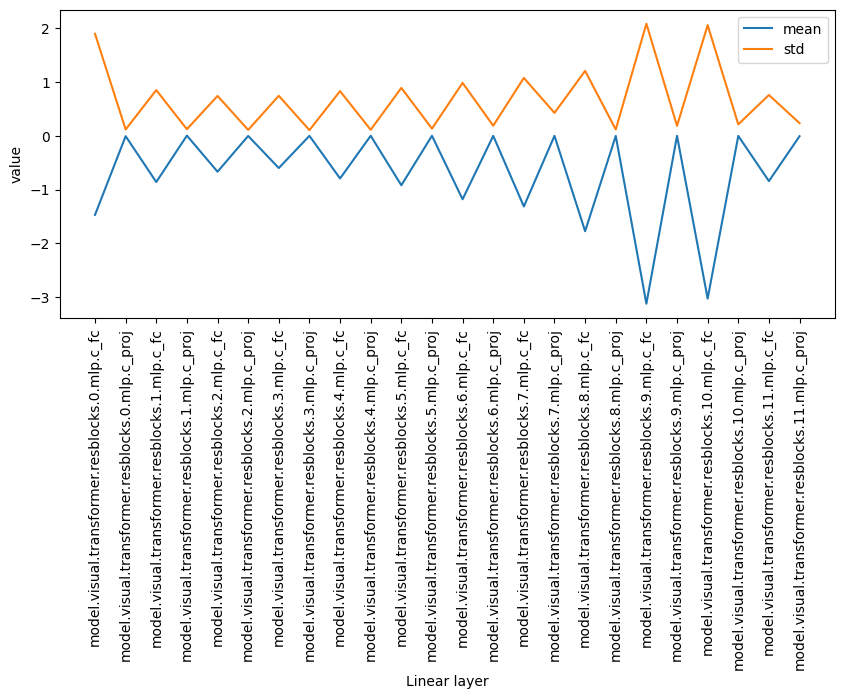

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

names = list(stats.keys())
means = [stats[k][0] for k in names]
stds  = [stats[k][1] for k in names]

plt.figure(figsize=(10, 4))
sns.lineplot(x=range(len(means)), y=means, label="mean")
sns.lineplot(x=range(len(stds)),  y=stds,  label="std")

plt.xticks(range(len(names)), names, rotation=90)
plt.ylabel("value")
plt.xlabel("Linear layer")
plt.tight_layout()
plt.show()
